[1] 모듈 로딩<hr>

In [30]:
import pandas as pd                 ## 분석용
import numpy as np                  ## 
from statsmodels import robust
import matplotlib.pyplot as plt
import koreanize_matplotlib

[2] 데이터 준비 <hr>

In [31]:
## 데이터 파일
data_file = '../DATA/state.csv'
statedf = pd.read_csv(data_file)
statedf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


[3] 데이터 산포도 <hr>

In [32]:
## ========================================================================
## 표준편차, 사분위수, 중위절대편차
## ========================================================================
## pandas
print(f' 표준편차 : {statedf["Population"].std()}')
print(f' 1사분위수 : {statedf["Population"].quantile(0.25)}')
print(f' 3사분위수 : {statedf["Population"].quantile(0.75)}')
print(f' 사분위수범위 : {statedf["Population"].quantile(0.75) - statedf["Population"].quantile(0.25)}')

## numpy
print(f' 표준편차 : {np.std(statedf["Population"])}')
print(f' 1사분위수 : {np.quantile(statedf["Population"], 0.25)}')
print(f' 3사분위수 : {np.quantile(statedf["Population"], 0.75)}')

print(f' 중위절대편차 : {robust.mad(statedf["Population"])}')




 표준편차 : 6848235.347401142
 1사분위수 : 1833004.25
 3사분위수 : 6680312.25
 사분위수범위 : 4847308.0
 표준편차 : 6779407.114632265
 1사분위수 : 1833004.25
 3사분위수 : 6680312.25
 중위절대편차 : 3849876.1459979336


[4] 데이터 분포 시각화 - 상자그림 Boxplot <hr>

In [33]:
## 인구수 분포 시각화
dataSR = statedf["Population"]/1_000_000

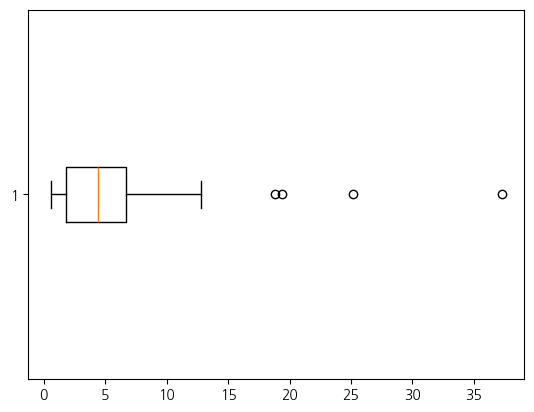

In [34]:
## 상자그래프 시각화
retDict = plt.boxplot(dataSR, vert=False)
plt.show()


In [38]:
## 상자그래프 결과 => dict
for key in retDict :
    print(key)

outliers = retDict['fliers'][0]
print(outliers.get_xdata())

whiskers
caps
boxes
medians
fliers
means
[37.253956 18.80131  19.378102 25.145561]


[4] 데이터 분포 시각화 - 도수분포표/히스토그램

Population
L-0     24
L-1     14
L-2      6
L-3      2
L-4      1
L-5      1
L-6      1
L-9      1
L-7      0
L-8      0
Name: count, dtype: int64

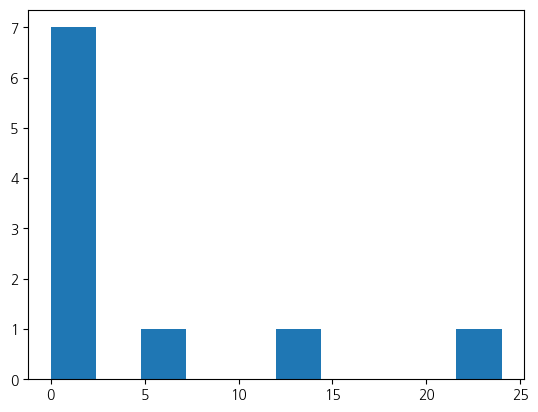

In [65]:
## 수치형 => 범주형 변환. 구간(bins)별로 데이터를 묶어주기
sr, bins = pd.cut(statedf['Population'], bins=10, retbins=True, labels=[f'L-{idx} 'for idx in range(10)])

## 도수분포표
dataSR = sr.value_counts()
display(dataSR)

##시각화
plt.hist(dataSR, label=[f'L-{idx} 'for idx in range(10)])
plt.show()

(array([7., 0., 1., 0., 0., 1., 0., 0., 0., 1.]),
 array([ 0. ,  2.4,  4.8,  7.2,  9.6, 12. , 14.4, 16.8, 19.2, 21.6, 24. ]),
 <BarContainer object of 10 artists>)

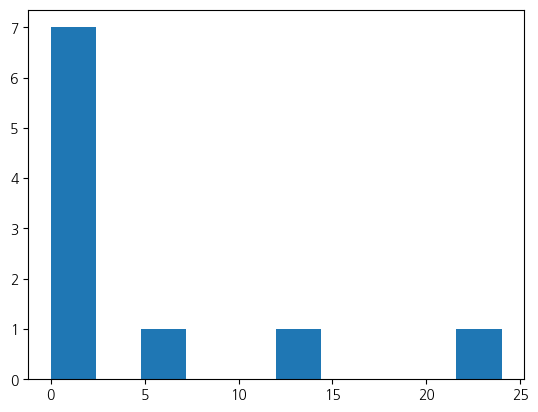